# 30 Day Hospital Readmission Prediction and Risk Factor Identification for Diabetic Patients
Independent Project by Benjamin Ly

University of California San Diego Masters of Data Science student

# Research Question

<p>In addition to the important work that hospitals and doctors do, another variable that would be interesting to look at to help patients stay healthy is the readmission rate. It would also be beneficial to look at identifiable factors that can help tell us why they are being readmitted or give us the ability to label them as at risk of readmission. Most common practice is to look at patients readmitted within 30 days (<30). To tackle this problem I am using a publicly available dataset from the UC Irvine Machine Learning Repository, Diabetes 130-US Hospitals for Years 1999-2008. The dataset consists of approximately 100,000 patients and features covering age, what medication they are on, change in dosage of medication, number of procedures performed, and their diagnosed with during their hospitalization using ICD-9 codes.<p>

To approach the actual problem I will be applying Logistic regression, Decisiont trees, Support vector machines, Random Forest, and XGBoost to the dataset. Additionally, there was a major problem with class imbalance after data cleaning that I attempted to fix using SMOTENC. Unfortunately SMOTENC worsened the performance of each model.

# Imports

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

from scipy.stats import loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score

# Data import and Exploratory Analysis

In [73]:
#import dataset from UCI ML Repo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [74]:
#combine the separated datasets into one for easier manipulation and cleaning
full_data = pd.concat([X, y], axis=1)
full_data.head(10)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,Male,[50-60),NaN,2,1,2,3,NaN,NaN,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,Caucasian,Male,[60-70),NaN,3,1,2,4,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,Caucasian,Male,[70-80),NaN,1,1,7,5,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,>30
8,Caucasian,Female,[80-90),NaN,2,1,4,13,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,Caucasian,Female,[90-100),NaN,3,3,4,12,NaN,InternalMedicine,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [75]:
full_data.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [76]:
full_data.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


<Axes: >

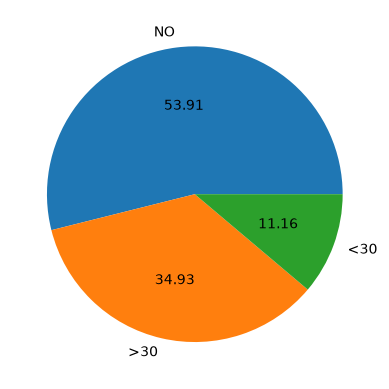

In [77]:
full_data['readmitted'].value_counts().plot.pie(autopct='%.2f')

Text(0.5, 0, 'Admission Type ID')

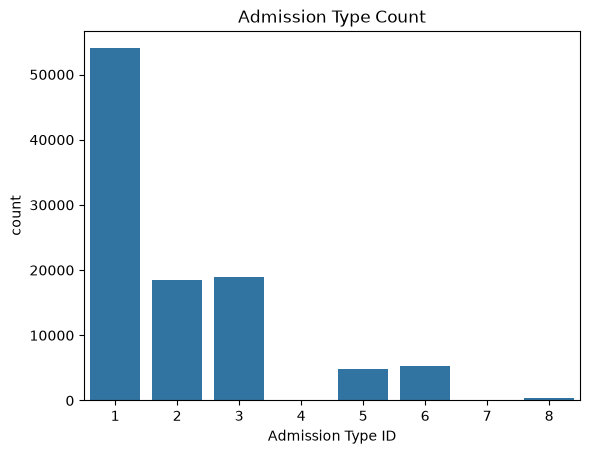

In [78]:
#observe distribution of admission type
admission_type_col = full_data['admission_type_id'].value_counts()

sns.barplot(data=admission_type_col)
plt.title('Admission Type Count')
plt.xlabel('Admission Type ID')

#Admission Type ID:
#- 1 = Emergency
#- 2 = Urgent
#- 3 = Elective
#- 4 = Newborn
#- 5 = N/A
#- 6 = NULL
#- 7 = Trauma Center
#- 8 =Not Mapped

Text(0.5, 0, 'Admission Source ID')

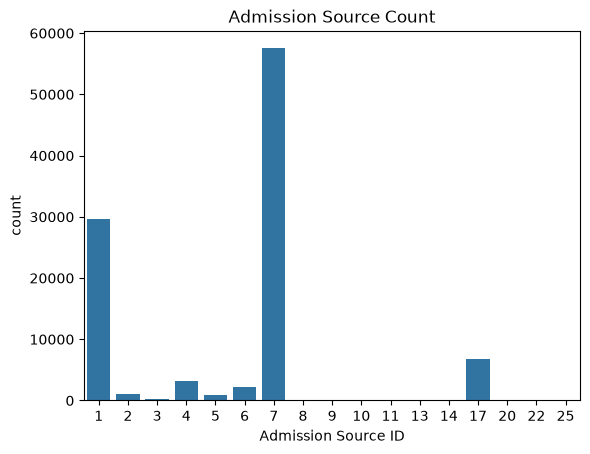

In [79]:
admission_source_col = X['admission_source_id'].value_counts()

sns.barplot(data=admission_source_col)
plt.title('Admission Source Count')
plt.xlabel('Admission Source ID')

#Most Prominent Admission Source ID:
#- 1 = Physician Referral
#- 7 = Emergency Room
#- 17 = Null 

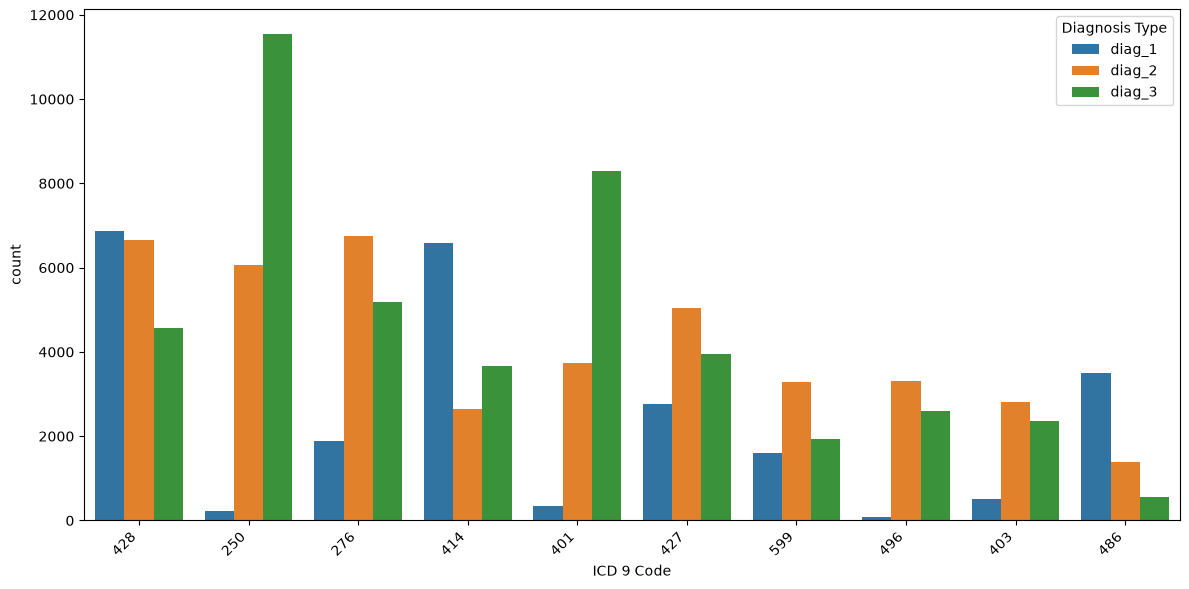

In [80]:
diag_long = pd.melt(
    full_data[['diag_1', 'diag_2', 'diag_3']],
    var_name='Diagnosis Type',
    value_name='ICD 9 Code'
)

plt.figure(figsize=(12, 6))
top_codes = diag_long['ICD 9 Code'].value_counts().head(10).index
sns.countplot(data=diag_long[diag_long['ICD 9 Code'].isin(top_codes)],
              x='ICD 9 Code', hue='Diagnosis Type',
              order=top_codes)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 428, 414, 401, 427, & 403 = Diseases of the circulatory system
# 250 & 276 = Endocrine, nutritional and metabolic diseases, and immunity disorders
# 599 = Diseases of the genitourinary system
# 496 & 486 = Diseases of the respiratory system
# The top 10 most frequently occurring diagnosis
# Most frequently occurring chapter of code is disease of the circulatory system (Heart disease) 

In [81]:
# Percentage of missing values per feature
missing_pct = (X.isnull().sum() / len(X)) * 100

# Filter and display only features with missing values
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(missing_pct.to_string())

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636


In [82]:
#remove weight, medical_specialty and payer code 
#because of the large amount of missing values
copy_df = full_data.drop(columns=['weight', 'medical_specialty', 'payer_code', 'max_glu_serum', 'A1Cresult'])
copy_df.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,Caucasian,Male,[60-70),3,1,2,4,70,1,21,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,Caucasian,Male,[70-80),1,1,7,5,73,0,12,...,No,No,No,No,No,No,No,No,Yes,>30
8,Caucasian,Female,[80-90),2,1,4,13,68,2,28,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,Caucasian,Female,[90-100),3,3,4,12,33,3,18,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [83]:
#age and gender are both later numerically mapped
categorical_features = ['race', 'gender', 'change', 'diabetesMed']

medicine_featuers = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 
                        'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
                        'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

In [84]:
#female == 0, male == 1
copy_df['gender'] = (copy_df['gender'] == 'Male').astype(int)

copy_df['change'] = (copy_df['change'] == 'Ch').astype(int) 

copy_df['diabetesMed'] = (copy_df['diabetesMed'] == 'No').astype(int)

age_mapping = {
    '[0-10)': 1,
    '[10-20)': 2,
    '[20-30)': 3,
    '[30-40)': 4,
    '[40-50)': 5,
    '[50-60)': 6,
    '[60-70)': 7,
    '[70-80)': 8,
    '[80-90)': 9,
    '[90-100)': 10
}

copy_df['age'] = copy_df['age'].map(age_mapping)

#convert to binary so I am only predicting >30 days readmission
#1 == <30 readmission, 0 == NO or >30 day readmission
copy_df['readmitted'] = (copy_df['readmitted'] == '<30').astype(int)

In [85]:
copy_df.shape

(101766, 43)

In [86]:
copy_df.isna().any(axis=None)

np.True_

# Data Processing for ML

In [87]:
#copy data so that original dataset can be used later in project
ml_data = copy_df.copy()

#integer map the medicine features
med_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

for col in medicine_featuers:
    if col in ml_data.columns:
        ml_data[col] = ml_data[col].map(med_mapping)

ml_data = ml_data.drop(columns=['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id','race'])

ml_data.head(10)

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,0,1,1,41,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0,2,3,59,0,18,0,0,0,9,...,0,3,0,0,0,0,0,1,0,0
2,0,3,2,11,5,13,2,0,1,6,...,0,0,0,0,0,0,0,0,0,0
3,1,4,2,44,1,16,0,0,0,7,...,0,3,0,0,0,0,0,1,0,0
4,1,5,1,51,0,8,0,0,0,5,...,0,1,0,0,0,0,0,1,0,0
5,1,6,3,31,6,16,0,0,0,9,...,0,1,0,0,0,0,0,0,0,0
6,1,7,4,70,1,21,0,0,0,7,...,0,1,0,0,0,0,0,1,0,0
7,1,8,5,73,0,12,0,0,0,8,...,0,0,0,0,0,0,0,0,0,0
8,0,9,13,68,2,28,0,0,0,8,...,0,1,0,0,0,0,0,1,0,0
9,0,10,12,33,3,18,0,0,0,8,...,0,1,0,0,0,0,0,1,0,0


In [88]:
#Isolate target variable
train_feat = ml_data.drop(columns=['readmitted'])
target = ml_data['readmitted']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(ml_data)
ml_data = pd.DataFrame(scaled_data, columns=ml_data.columns, index=ml_data.index)
ml_data.columns

#Split dataset so 20% is test, 80% is the remaining data
X_train_val, X_test, y_train_val, y_test = train_test_split(train_feat, target, test_size=0.2, random_state=42, stratify=target)

#Now split remaining dataset into validation and training set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

In [89]:
print(f"Number of rows in training set: {len(X_train), len(y_train)}")
print(f"Number of rows in validation set: {len(X_val), len(y_val)}")
print(f"Number of rows in test set: {len(X_test), len(y_test)}")

Number of rows in training set: (61059, 61059)
Number of rows in validation set: (20353, 20353)
Number of rows in test set: (20354, 20354)


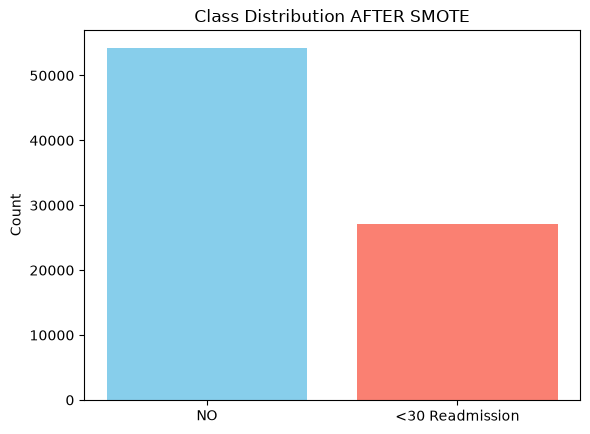

In [90]:
cat_cols = ['gender', 'age', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide','tolbutamide', 
            'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
            'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
            'metformin-pioglitazone', 'change', 'diabetesMed']

categorical_features = [X_train.columns.get_loc(c) for c in cat_cols]

smote = SMOTENC(sampling_strategy=0.5, random_state=42, categorical_features=categorical_features)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['NO', '<30 Readmission'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

# What machine learning classifier algorithm is best for predicting the readmission state (>30, <30, NO) for each diabetes patient?

The main goal of this research question is to try and build a meaningful model to predict the readmission state of a diabetic patient from the dataset. 

### Logistic Regression

In [91]:
readmitted_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42)
readmitted_pred_LogR.fit(X_train, y_train)

pred_train_LogR = readmitted_pred_LogR.predict(X_train)
pred_val_LogR = readmitted_pred_LogR.predict(X_val)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_LogR)}")
print(confusion_matrix(y_train, pred_train_LogR))

Training accuracy: 0.8881409783979429
[[54139   105]
 [ 6725    90]]


In [92]:
readmitted_pred_LogR_SMOTE = LogisticRegression(max_iter = 1000, random_state= 42)
readmitted_pred_LogR_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_LogR_SMOTE = readmitted_pred_LogR_SMOTE.predict(X_train)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_LogR_SMOTE)}")
print(confusion_matrix(y_train, pred_train_LogR_SMOTE ))

Training accuracy: 0.8379436282939452
[[50223  4021]
 [ 5874   941]]


c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Decision Tree Classifier

In [93]:
readmitted_pred_DT = DecisionTreeClassifier(max_leaf_nodes=len(X.columns), random_state= 42)
readmitted_pred_DT.fit(X_train, y_train)

pred_train_DT = readmitted_pred_DT.predict(X_train)
pred_val_DT = readmitted_pred_DT.predict(X_val)

print(f"Decision Tree Training accuracy: {accuracy_score(y_train, pred_train_DT)}")
print(confusion_matrix(y_train, pred_train_DT))

Decision Tree Training accuracy: 0.8898114938010776
[[54175    69]
 [ 6659   156]]


In [94]:
readmitted_pred_DT_SMOTE = DecisionTreeClassifier(max_leaf_nodes=len(X.columns), random_state= 42)
readmitted_pred_DT_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_DT_SMOTE = readmitted_pred_DT_SMOTE.predict(X_train)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_DT_SMOTE)}")
print(confusion_matrix(y_train, pred_train_DT_SMOTE))

Training accuracy: 0.8796573805663375
[[53373   871]
 [ 6477   338]]


### SVM Classifier 

In [95]:
readmitted_pred_SVM = svm.SVC(kernel='rbf', random_state=42)
readmitted_pred_SVM.fit(X_train, y_train)

pred_train_SVM = readmitted_pred_SVM.predict(X_train)

print(f"SVM RBF CLF Training accuracy: {accuracy_score(y_train, pred_train_SVM)}")
print(confusion_matrix(y_train, pred_train_SVM))

SVM RBF CLF Training accuracy: 0.8883866424278157
[[54244     0]
 [ 6815     0]]


In [96]:
readmitted_pred_SVM_SMOTE = svm.SVC(kernel='rbf', random_state=42)
readmitted_pred_SVM_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_SVM_SMOTE = readmitted_pred_SVM_SMOTE.predict(X_train)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_SVM_SMOTE)}")
print(confusion_matrix(y_train, pred_train_SVM_SMOTE))

Training accuracy: 0.8880590903879854
[[54116   128]
 [ 6707   108]]


### Random Forest Classifier

In [97]:
readmitted_pred_RF = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
readmitted_pred_RF.fit(X_train, y_train)

pred_train_RF = readmitted_pred_RF.predict(X_train)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_RF)}")
print(confusion_matrix(y_train, pred_train_RF))

Training accuracy: 0.8943808447567108
[[54244     0]
 [ 6449   366]]


In [98]:
readmitted_pred_RF_SMOTE = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
readmitted_pred_RF_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_RF_SMOTE = readmitted_pred_RF_SMOTE.predict(X_train)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_RF_SMOTE)}")
print(confusion_matrix(y_train, pred_train_RF_SMOTE))

Training accuracy: 0.8742691495111286
[[52161  2083]
 [ 5594  1221]]


### XGBoost 

In [106]:
readmitted_xgb = xgb.XGBClassifier(random_state=42, device="cuda")

readmitted_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

pred_train_XGB = readmitted_xgb.predict(X_train)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_XGB)}")
print(confusion_matrix(y_train, pred_train_XGB))

c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:09:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:09:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Training accuracy: 0.8938731390949737
[[54221    23]
 [ 6457   358]]


In [107]:
readmitted_xgb_sm = xgb.XGBClassifier(random_state=42, device="cuda")

readmitted_xgb_sm.fit(X_train_sm, y_train_sm, eval_set=[(X_test, y_test)], verbose=False)

pred_train_XGB_sm = readmitted_xgb.predict(X_train)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_XGB_sm)}")
print(confusion_matrix(y_train, pred_train_XGB_sm))

c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:09:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Training accuracy: 0.8938731390949737
[[54221    23]
 [ 6457   358]]


### Model Comparison

In [108]:
#Logistic Regression Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_train, pred_train_LogR)
print(f"LogR Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_LogR))

accuracy = accuracy_score(y_train, pred_train_LogR_SMOTE)
print(f"LogR Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_LogR_SMOTE))


LogR Model Accuracy w/o SMOTE: 88.81%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     54244
           1       0.46      0.01      0.03      6815

    accuracy                           0.89     61059
   macro avg       0.68      0.51      0.48     61059
weighted avg       0.84      0.89      0.84     61059

LogR Model Accuracy w/ SMOTE: 83.79%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     54244
           1       0.19      0.14      0.16      6815

    accuracy                           0.84     61059
   macro avg       0.54      0.53      0.54     61059
weighted avg       0.82      0.84      0.83     61059



In [109]:
#Decisiion Tree Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_train, pred_train_DT)
print(f"DT Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_DT))

accuracy = accuracy_score(y_train, pred_train_DT_SMOTE)
print(f"DT Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_DT_SMOTE))

DT Model Accuracy w/o SMOTE: 88.98%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     54244
           1       0.69      0.02      0.04      6815

    accuracy                           0.89     61059
   macro avg       0.79      0.51      0.49     61059
weighted avg       0.87      0.89      0.84     61059

DT Model Accuracy w/ SMOTE: 87.97%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     54244
           1       0.28      0.05      0.08      6815

    accuracy                           0.88     61059
   macro avg       0.59      0.52      0.51     61059
weighted avg       0.82      0.88      0.84     61059



In [110]:
#SVM Classifier Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_train, pred_train_SVM)
print(f"SVM Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_SVM))

accuracy = accuracy_score(y_train, pred_train_SVM_SMOTE)
print(f"SVM Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_SVM_SMOTE))

SVM Model Accuracy w/o SMOTE: 88.84%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     54244
           1       0.00      0.00      0.00      6815

    accuracy                           0.89     61059
   macro avg       0.44      0.50      0.47     61059
weighted avg       0.79      0.89      0.84     61059

SVM Model Accuracy w/ SMOTE: 88.81%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     54244
           1       0.46      0.02      0.03      6815

    accuracy                           0.89     61059
   macro avg       0.67      0.51      0.49     61059
weighted avg       0.84      0.89      0.84     61059



c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

In [111]:
#Random Forest Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_train, pred_train_RF)
print(f"RF Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_RF))

accuracy = accuracy_score(y_train, pred_train_RF_SMOTE)
print(f"RF Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_RF_SMOTE))

RF Model Accuracy w/o SMOTE: 89.44%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     54244
           1       1.00      0.05      0.10      6815

    accuracy                           0.89     61059
   macro avg       0.95      0.53      0.52     61059
weighted avg       0.91      0.89      0.85     61059

RF Model Accuracy w/ SMOTE: 87.43%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     54244
           1       0.37      0.18      0.24      6815

    accuracy                           0.87     61059
   macro avg       0.64      0.57      0.59     61059
weighted avg       0.84      0.87      0.85     61059



In [115]:
#XGBoost Performance w/o SMOTE
accuracy = accuracy_score(y_train, pred_train_XGB)
print(f"XGBoost Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_XGB))

accuracy = accuracy_score(y_train, pred_train_XGB_sm)
print(f"XGBoost Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_train, pred_train_XGB_sm))

XGBoost Model Accuracy w/o SMOTE: 89.39%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     54244
           1       0.94      0.05      0.10      6815

    accuracy                           0.89     61059
   macro avg       0.92      0.53      0.52     61059
weighted avg       0.90      0.89      0.85     61059

XGBoost Model Accuracy w/ SMOTE: 89.39%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     54244
           1       0.94      0.05      0.10      6815

    accuracy                           0.89     61059
   macro avg       0.92      0.53      0.52     61059
weighted avg       0.90      0.89      0.85     61059



### Area Under the Receiver Operating Characteristic curve (AUROC)

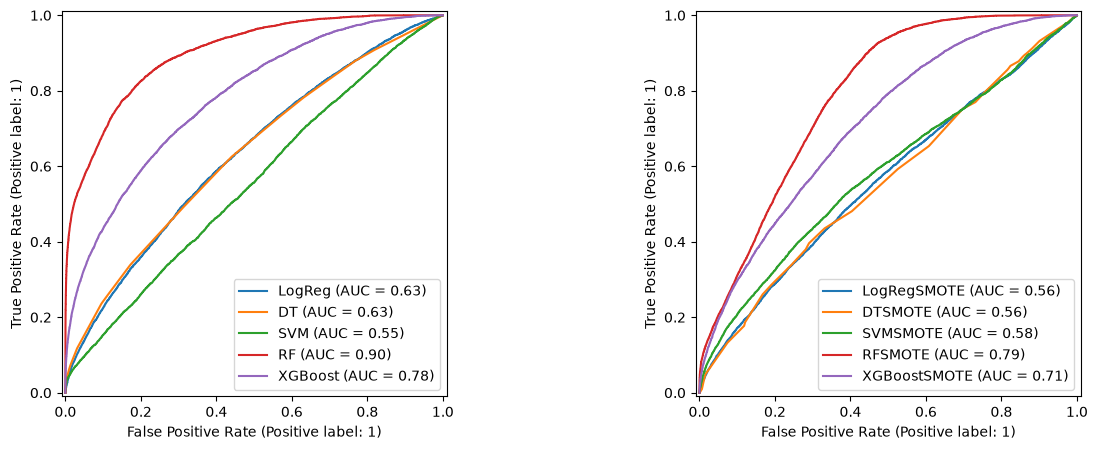

In [113]:
#AUROC graphs
fig, ax = plt.subplots(1,2, figsize = (15,5))
RocCurveDisplay.from_estimator(readmitted_pred_LogR, X_train, y_train, ax=ax[0], name="LogReg")
RocCurveDisplay.from_estimator(readmitted_pred_DT, X_train, y_train, ax=ax[0], name="DT")
RocCurveDisplay.from_estimator(readmitted_pred_SVM, X_train, y_train, ax=ax[0], name="SVM")
RocCurveDisplay.from_estimator(readmitted_pred_RF, X_train, y_train, ax=ax[0], name="RF")
RocCurveDisplay.from_estimator(readmitted_xgb, X_train, y_train, ax=ax[0], name="XGBoost")

RocCurveDisplay.from_estimator(readmitted_pred_LogR_SMOTE, X_train, y_train, ax=ax[1], name="LogRegSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_DT_SMOTE, X_train, y_train, ax=ax[1], name="DTSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_SVM_SMOTE, X_train, y_train, ax=ax[1], name="SVMSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_RF_SMOTE, X_train, y_train, ax=ax[1], name="RFSMOTE")
RocCurveDisplay.from_estimator(readmitted_xgb_sm, X_train, y_train, ax=ax[1], name="XGBoostSMOTE")

plt.show()

### Area Under the Precision-Recall Curve (AUPRC)

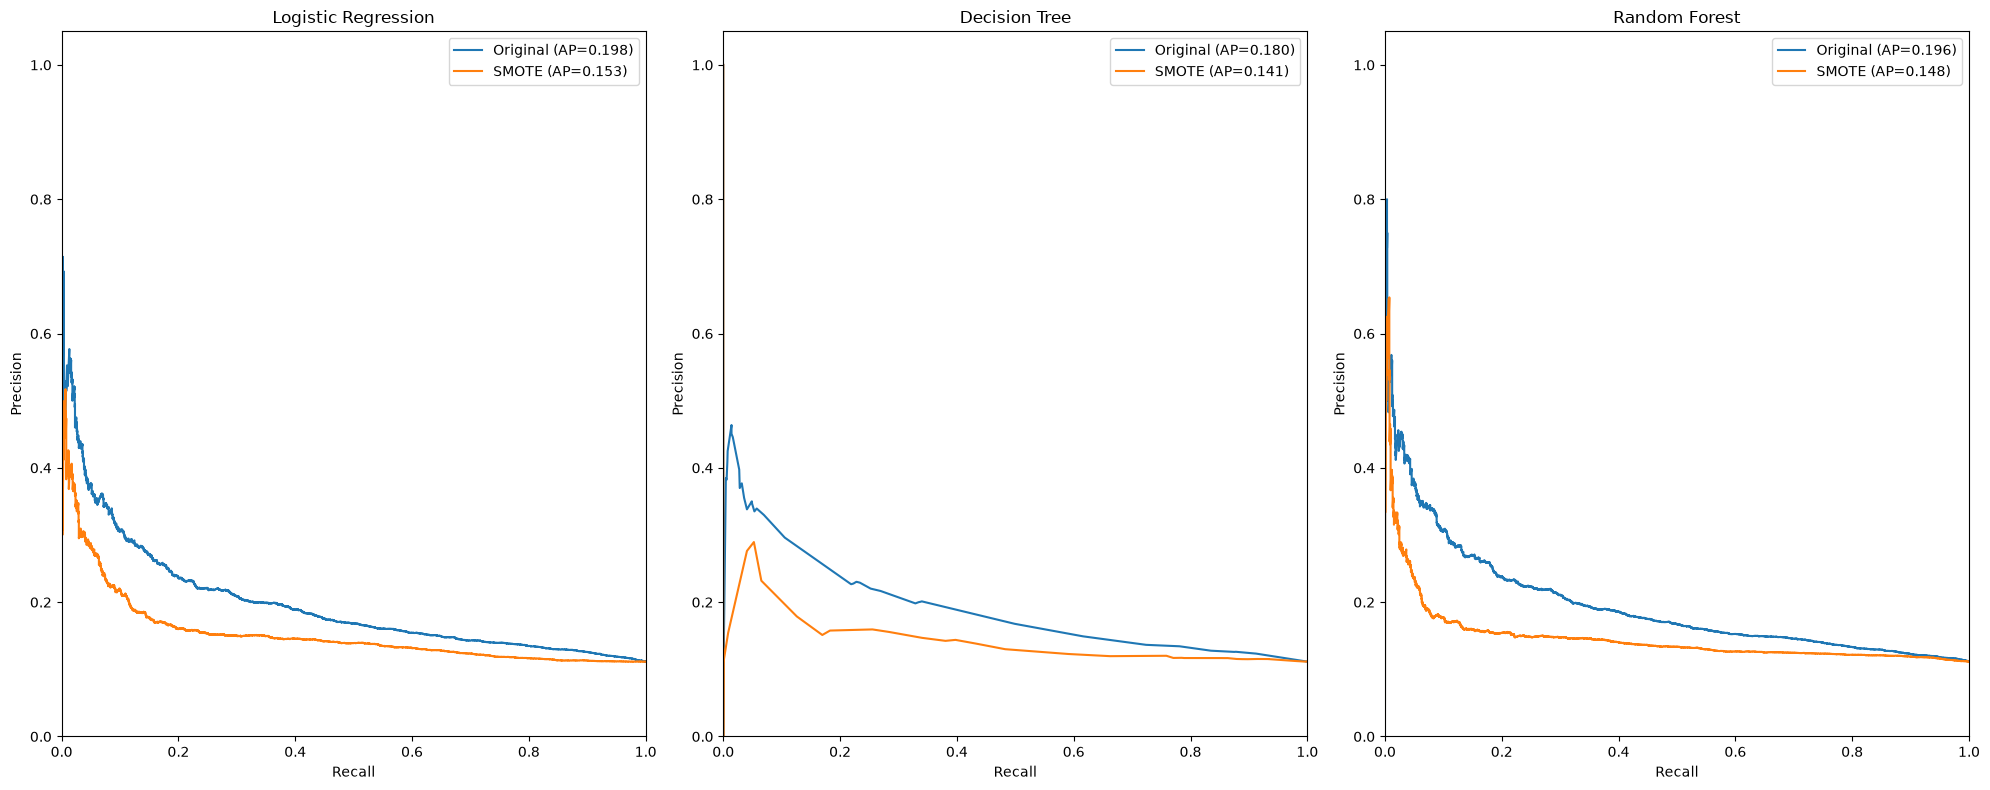

In [114]:
#AUPRC Graphs
model_groups = {
    "Logistic Regression": {
        "Original": readmitted_pred_LogR,
        "SMOTE": readmitted_pred_LogR_SMOTE,
    },
    "Decision Tree": {
        "Original": readmitted_pred_DT,
        "SMOTE": readmitted_pred_DT_SMOTE,
    },
    "Random Forest": {
        "Original": readmitted_pred_RF,
        "SMOTE": readmitted_pred_RF_SMOTE,
    },
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes = axes.ravel()  # flatten 2x2 grid into a list of 4 for easy indexing

for ax, (algo_name, variants) in zip(axes, model_groups.items()):
    for label, model in variants.items():
        y_prob = model.predict_proba(X_val)[:, 1]  # always score on validation, both variants
        precision, recall, _ = precision_recall_curve(y_val, y_prob)
        ap = average_precision_score(y_val, y_prob)
        ax.plot(recall, precision, label=f"{label} (AP={ap:.3f})")

    ax.set_title(algo_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

Comparing AUROC and recall scores for class 1 (<30 day readmission), we can confirm that XGBoost and Random Forest performed the best. Additionally, SMOTE did not help with class imbalance, it actually ended up hurting the model performance.

Next step is to take the Random Forest model and tune the hyperparameters using RandomizedSearchCV, fitting it to the validation set. After this step then we can test the best Random Forest model on the test set.

In [116]:
rf_params = {
    'n_estimators': [100, 200, 300, 500, 750, 1000],

    'max_depth': [None, 5, 10, 15, 20, 30, 40],

    'min_samples_split': [2, 5, 10, 20, 50],

    'min_samples_leaf': [1, 2, 4, 5, 10, 20],

    'max_features': ['sqrt', 'log2', None],

    'bootstrap': [True, False],

    'class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_random_search = RandomizedSearchCV(
    estimator=readmitted_pred_RF,
    param_distributions=rf_params,
    n_iter=50,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

rf_random_search.fit(X_val, y_val)

print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(rf_random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': True}

Best Cross-Validation F1 Score:
0.254713870328362


In [125]:
best_rf = rf_random_search.best_estimator_

pred_test_RF_tuned = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, pred_test_RF_tuned)
print(f"Tuned Random Forest Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print(classification_report(y_test, pred_test_RF_tuned))
print(f"Confusion Matrix for tuned model: \n{confusion_matrix(y_test, pred_test_RF_tuned)}")


Tuned Random Forest Model Accuracy w/o SMOTE: 70.46%

              precision    recall  f1-score   support

           0       0.92      0.74      0.82     18083
           1       0.18      0.46      0.26      2271

    accuracy                           0.70     20354
   macro avg       0.55      0.60      0.54     20354
weighted avg       0.83      0.70      0.75     20354

Confusion Matrix for tuned model: 
[[13306  4777]
 [ 1236  1035]]


# Stratified Analysis Across Race
To take into consideration how the model performs on different races, I decided to instead do a stratified analysis across the races rather than feeding the data into the model.

This also checks for any accidental racial bias that may have been introduced into the model during it's training period.

In [128]:
race_data = copy_df.copy()

#apply map to medication columns
med_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

for col in medicine_featuers:
    if col in race_data.columns:
        race_data[col] = race_data[col].map(med_mapping)

race_data = race_data.drop(columns=['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id'])

asian_data = race_data[race_data['race'] == 'Asian']
caucasian_data = race_data[race_data['race'] == 'Caucasian']
africanamerican_data = race_data[race_data['race'] == 'AfricanAmerican']
hispanic_data = race_data[race_data['race'] == 'Hispanic']
other_data = race_data[race_data['race'] == 'Other']


### Asian Data

In [129]:
#split data
asian_train_feat = asian_data.drop(columns=['readmitted', 'race'])
asian_target = asian_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_asian, X_test_asian, y_train_val_asian, y_test_asian = train_test_split(asian_train_feat, asian_target, test_size=0.2, random_state=42, stratify=asian_target)

#Now split remaining dataset into validation and training set
X_train_asian, X_val_asian, y_train_asian, y_val_asian = train_test_split(X_train_val_asian, y_train_val_asian, test_size=0.25, random_state=42, stratify=y_train_val_asian)

In [131]:
best_rf.fit(X_train_asian, y_train_asian)

asian_pred_train_rf = best_rf.predict(X_train_asian)
asian_pred_val_rf = best_rf.predict(X_val_asian)
asian_pred_test_rf = best_rf.predict(X_test_asian)

print(f"Training accuracy on Asian set: {accuracy_score(y_train_asian, asian_pred_train_rf)}")
print(f"Validation accuracy on Asian set: {accuracy_score(y_val_asian, asian_pred_val_rf)}")
print(f"Testing accuracy on Asian set: {accuracy_score(y_test_asian, asian_pred_test_rf)}")
print(confusion_matrix(y_test_asian, asian_pred_test_rf))

Training accuracy on Asian set: 0.796875
Validation accuracy on Asian set: 0.8359375
Testing accuracy on Asian set: 0.7054263565891473
[[89 27]
 [11  2]]


In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        best_rf,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### Caucasian Data  

In [ ]:
#split data
caucasian_train_feat = caucasian_data.drop(columns=['readmitted', 'race'])
caucasian_target = caucasian_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_caucasian, X_test_caucasian, y_train_val_caucasian, y_test_caucasian = train_test_split(caucasian_train_feat, caucasian_target, test_size=0.2, random_state=42, stratify=caucasian_target)

#Now split remaining dataset into validation and training set
X_train_caucasian, X_val_caucasian, y_train_caucasian, y_val_caucasian = train_test_split(X_train_val_caucasian, y_train_val_caucasian, test_size=0.25, random_state=42, stratify=y_train_val_caucasian)

In [ ]:
caucasian_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
caucasian_pred_LogR.fit(X_train_asian, y_train_asian)

caucasian_pred_train_LogR = caucasian_pred_LogR.predict(X_train_caucasian)
caucasian_pred_val_LogR = caucasian_pred_LogR.predict(X_val_caucasian)
caucasian_pred_test_logR = caucasian_pred_LogR.predict(X_test_caucasian)

print(f"Training accuracy on caucasian set: {accuracy_score(y_train_caucasian, caucasian_pred_train_LogR)}")
print(f"Validation accuracy on caucasian set: {accuracy_score(y_val_caucasian, caucasian_pred_val_LogR)}")
print(f"Testing accuracy on caucasian set: {accuracy_score(y_test_caucasian, caucasian_pred_test_logR)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        caucasian_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### African American Data

In [ ]:
#split data
africanamerican_train_feat = africanamerican_data.drop(columns=['readmitted', 'race'])
africanamerican_target = africanamerican_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_africanamerican, X_test_africanamerican, y_train_val_africanamerican, y_test_africanamerican = train_test_split(africanamerican_train_feat, africanamerican_target, test_size=0.2, random_state=42, stratify=africanamerican_target)

#Now split remaining dataset into validation and training set
X_train_africanamerican, X_val_africanamerican, y_train_africanamerican, y_val_africanamerican = train_test_split(X_train_val_africanamerican, y_train_val_africanamerican, test_size=0.25, random_state=42, stratify=y_train_val_africanamerican)

In [ ]:
africanamerican_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
africanamerican_pred_LogR.fit(X_train_asian, y_train_asian)

africanamerican_pred_train_LogR = africanamerican_pred_LogR.predict(X_train_africanamerican)
africanamerican_pred_val_LogR = africanamerican_pred_LogR.predict(X_val_africanamerican)
africanamerican_pred_test_logR = africanamerican_pred_LogR.predict(X_test_africanamerican)

print(f"Training accuracy on african american set: {accuracy_score(y_train_africanamerican, africanamerican_pred_train_LogR)}")
print(f"Validation accuracy on african american set: {accuracy_score(y_val_africanamerican, africanamerican_pred_val_LogR)}")
print(f"Testing accuracy on african american set: {accuracy_score(y_test_africanamerican, africanamerican_pred_test_logR)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        africanamerican_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### Hispanic Data 

In [ ]:
#split data
hispanic_train_feat = hispanic_data.drop(columns=['readmitted', 'race'])
hispanic_target = hispanic_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_hispanic, X_test_hispanic, y_train_val_hispanic, y_test_hispanic = train_test_split(hispanic_train_feat, hispanic_target, test_size=0.2, random_state=42, stratify=hispanic_target)

#Now split remaining dataset into validation and training set
X_train_hispanic, X_val_hispanic, y_train_hispanic, y_val_hispanic = train_test_split(X_train_val_hispanic, y_train_val_hispanic, test_size=0.25, random_state=42, stratify=y_train_val_hispanic)

In [ ]:
hispanic_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
hispanic_pred_LogR.fit(X_train_hispanic, y_train_hispanic)

hispanic_pred_train_LogR = hispanic_pred_LogR.predict(X_train_hispanic)
hispanic_pred_val_LogR = hispanic_pred_LogR.predict(X_val_hispanic)
hispanic_pred_test_logR = hispanic_pred_LogR.predict(X_test_hispanic)

print(f"Training accuracy on hispanic set: {accuracy_score(y_train_hispanic, hispanic_pred_train_LogR)}")
print(f"Validation accuracy on hispanic set: {accuracy_score(y_val_hispanic, hispanic_pred_val_LogR)}")
print(f"Testing accuracy on hispanic set: {accuracy_score(y_test_hispanic, hispanic_pred_test_logR)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        hispanic_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### Other Race Data

In [ ]:
#split data
other_train_feat = other_data.drop(columns=['readmitted', 'race'])
other_target = other_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_other, X_test_other, y_train_val_other, y_test_other = train_test_split(other_train_feat, other_target, test_size=0.2, random_state=42, stratify=other_target)

#Now split remaining dataset into validation and training set
X_train_other, X_val_other, y_train_other, y_val_other = train_test_split(X_train_val_other, y_train_val_other, test_size=0.25, random_state=42, stratify=y_train_val_other)

In [ ]:
other_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
other_pred_LogR.fit(X_train_other, y_train_other)

other_train_LogR = other_pred_LogR.predict(X_train_other)
other_val_LogR = other_pred_LogR.predict(X_val_other)
other_test_LogR = other_pred_LogR.predict(X_test_other)

print(f"Training accuracy on other set: {accuracy_score(y_train_other, other_train_LogR)}")
print(f"Validation accuracy on other set: {accuracy_score(y_val_other, other_val_LogR)}")
print(f"Testing accuracy on other set: {accuracy_score(y_test_other, other_test_LogR)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        other_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29